In [1]:
# Task 1 : Data Preprocessing

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, davies_bouldin_score
df = pd.read_csv("EastWestAirlines_csv.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [32]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [33]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [34]:
df = df.drop(columns=['ID#'])

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

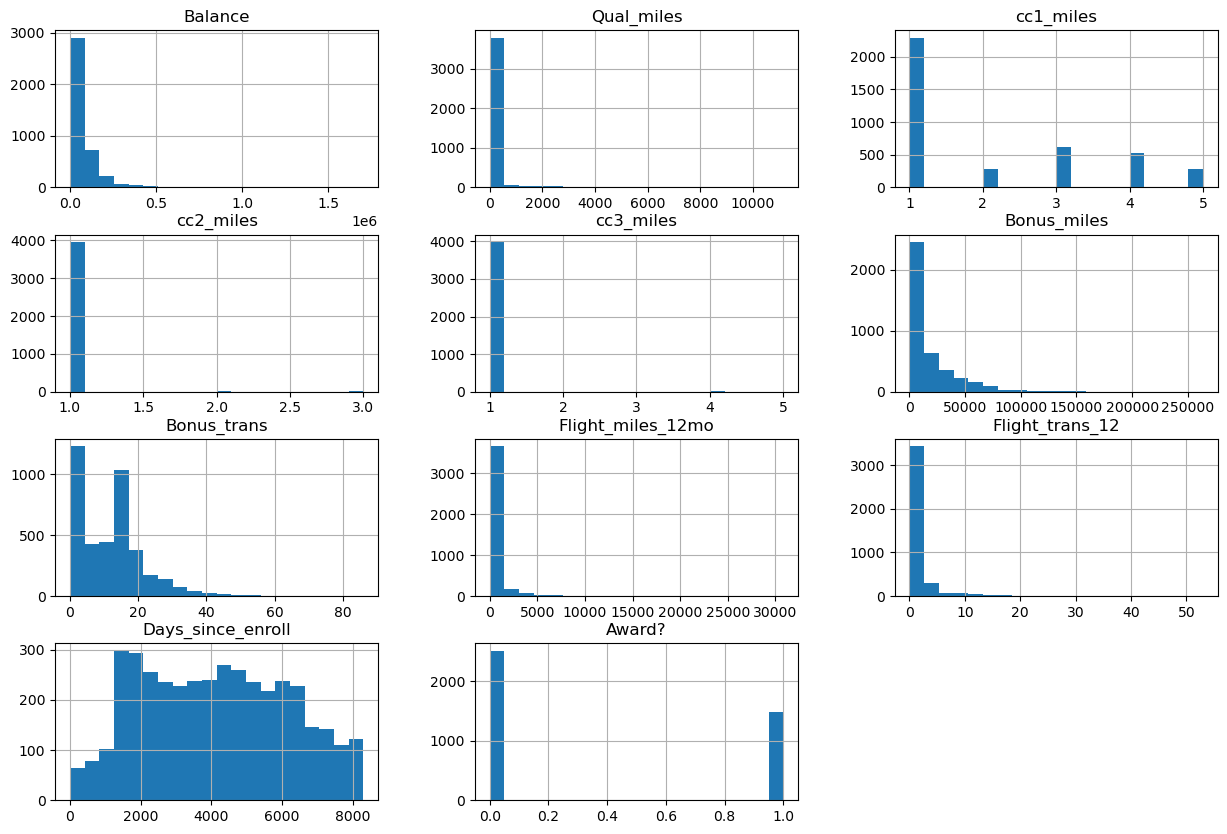

In [36]:
df.hist(bins=20, figsize=(15, 10))
plt.show()

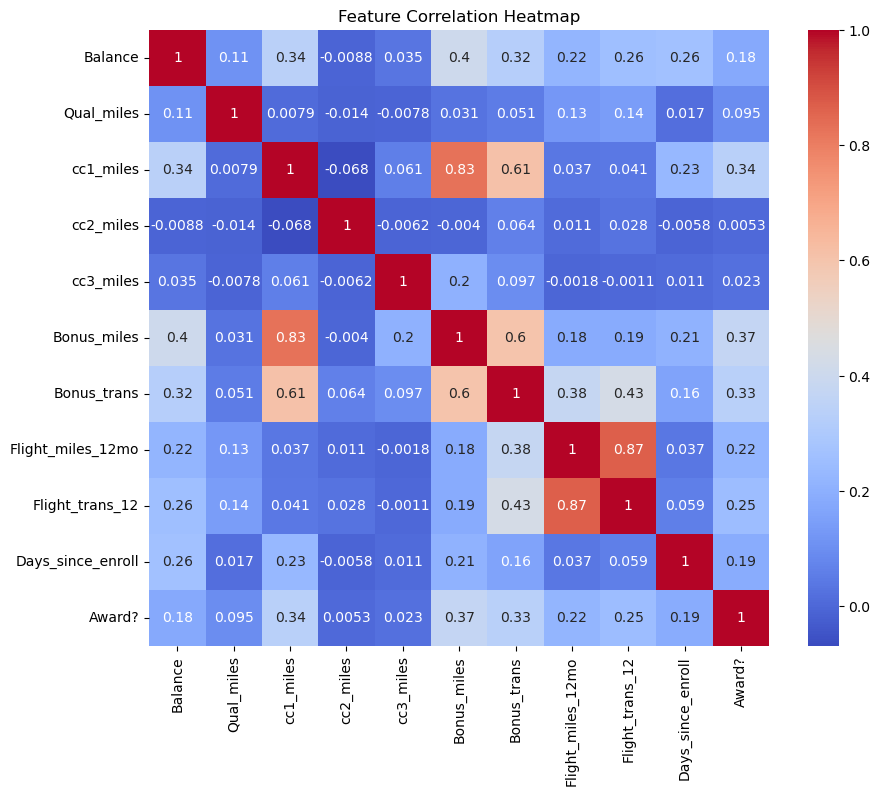

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

<Axes: xlabel='Balance', ylabel='Bonus_miles'>

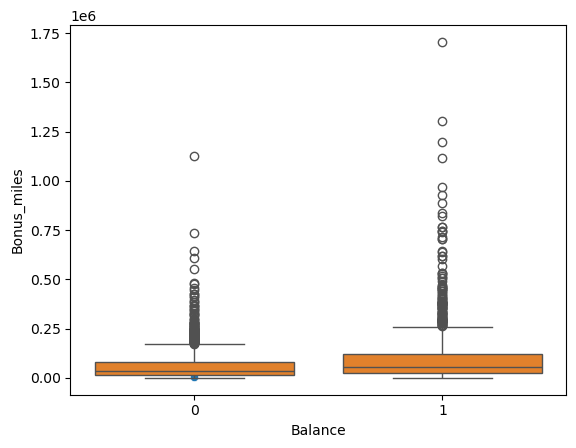

In [38]:
sns.scatterplot(x='Balance', y='Bonus_miles', data=df)
sns.boxplot(x='Award?', y='Balance', data=df)

In [39]:
(df == 0).mean() * 100

Balance               0.025006
Qual_miles           94.348587
cc1_miles             0.000000
cc2_miles             0.000000
cc3_miles             0.000000
Bonus_miles          11.877969
Bonus_trans          11.877969
Flight_miles_12mo    68.092023
Flight_trans_12      68.092023
Days_since_enroll     0.000000
Award?               62.965741
dtype: float64

In [40]:
df = df.drop(columns=['Qual_miles'])

In [41]:
# As we see there are 94 % of zeroes in Qual_miles column which won't be useful in model building. Hence it is dropped.

In [42]:
# Task 2 : Implementing Clustering Algorithms

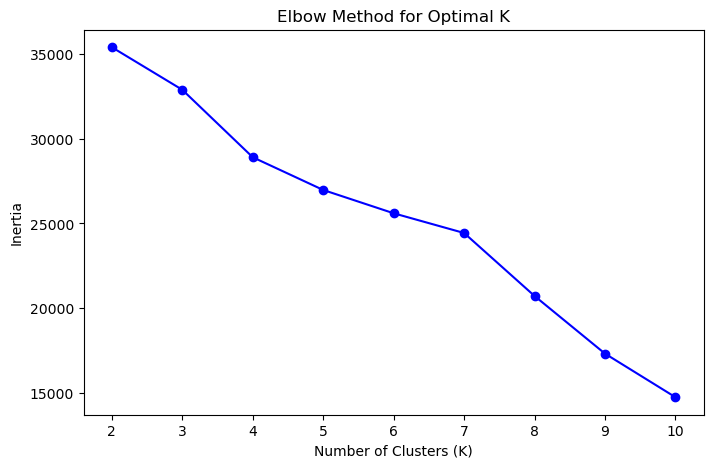

In [43]:
inertia = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [44]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    print(f"K={k}, Silhouette Score: {round(sil_score,3)}")

K=2, Silhouette Score: 0.325
K=3, Silhouette Score: 0.267
K=4, Silhouette Score: 0.191
K=5, Silhouette Score: 0.201
K=6, Silhouette Score: 0.211
K=7, Silhouette Score: 0.222
K=8, Silhouette Score: 0.231
K=9, Silhouette Score: 0.242
K=10, Silhouette Score: 0.261


In [60]:
# Kmeans Algorithm
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, df['Cluster_KMeans'])
db = davies_bouldin_score(X_scaled, df['Cluster_KMeans'])
print(f"K-Means Silhouette Score: {round(sil,3)}")
print(f"K-Means Davies–Bouldin Index: {round(db,3)}")
# K=5 produces more realistic sub-groups, but slightly lower Silhouette as some clusters overlap.

K-Means Silhouette Score: 0.201
K-Means Davies–Bouldin Index: 1.497


In [47]:
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 10]
for eps in eps_values:
    for min_s in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        print(f"eps={eps}, min_samples={min_s} → Clusters={n_clusters}, Noise={n_noise}")

eps=0.5, min_samples=3 → Clusters=40, Noise=1228
eps=0.5, min_samples=5 → Clusters=16, Noise=1413
eps=0.5, min_samples=10 → Clusters=9, Noise=1722
eps=1.0, min_samples=3 → Clusters=10, Noise=508
eps=1.0, min_samples=5 → Clusters=6, Noise=554
eps=1.0, min_samples=10 → Clusters=3, Noise=675
eps=1.5, min_samples=3 → Clusters=9, Noise=277
eps=1.5, min_samples=5 → Clusters=5, Noise=310
eps=1.5, min_samples=10 → Clusters=3, Noise=377
eps=2.0, min_samples=3 → Clusters=12, Noise=141
eps=2.0, min_samples=5 → Clusters=6, Noise=179
eps=2.0, min_samples=10 → Clusters=3, Noise=237


In [49]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

df['Cluster_DBSCAN'] = labels_db
if len(set(labels_db)) > 1:
    sil_db = silhouette_score(X_scaled, labels_db)
    db_db = davies_bouldin_score(X_scaled, labels_db)
    print(f"DBSCAN Silhouette Score: {round(sil_db,3)}")
    print(f"DBSCAN Davies–Bouldin Index: {round(db_db,3)}")
else:
    print("DBSCAN formed a single cluster or all noise.")

DBSCAN Silhouette Score: 0.254
DBSCAN Davies–Bouldin Index: 1.381


In [50]:
# Task 3 : Cluster Analysis

In [51]:
# Kmeans Clustering Analysis -
# Cluster Zero - > It includes those people who fly frequently. It has high values for columns like Balance, Bonus_miles etc
# Cluster One - > It includes those people who are new. It has low values for columns like Balance, Bonus_miles etc.
# Cluster Two - > It includes people who use credit cards for booking. It has high values for Bonus_miles but low value for Flight_trans_12mo.
# Cluster Three - > It includes moderate flyers. It has average values for Bonus_miles, Balance etc.
# Cluster Four - > It includes elite flyers. It has huge values for Balance, Bonus_miles etc.

In [52]:
# DBSCAN Clustering Analysis -
# Major Clusters(3-5) - > It represents moderate to frequent flyers as it is dense region.
# Noise(10-15%) - > It includes new flyers. It is used to detect unusal patterns.

In [53]:
# Task 4 : Visualization

In [55]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

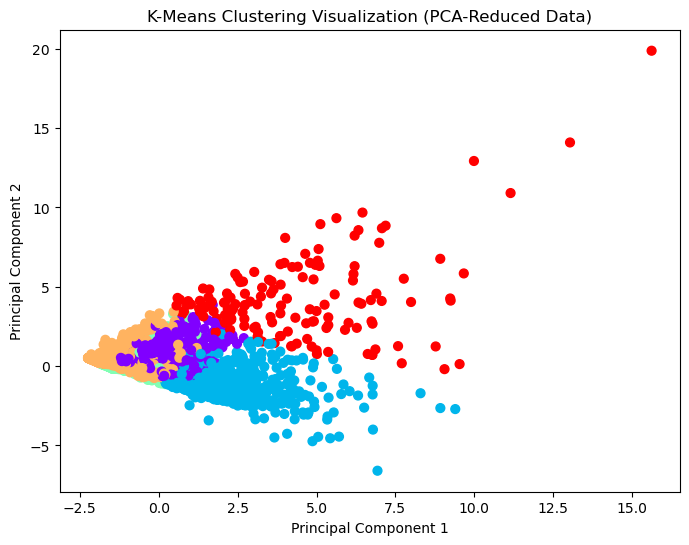

In [59]:
df_pca['KMeans_Cluster'] = kmeans.labels_
plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], 
            c=df_pca['KMeans_Cluster'], 
            cmap='rainbow', s=40)
plt.title("K-Means Clustering Visualization (PCA-Reduced Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

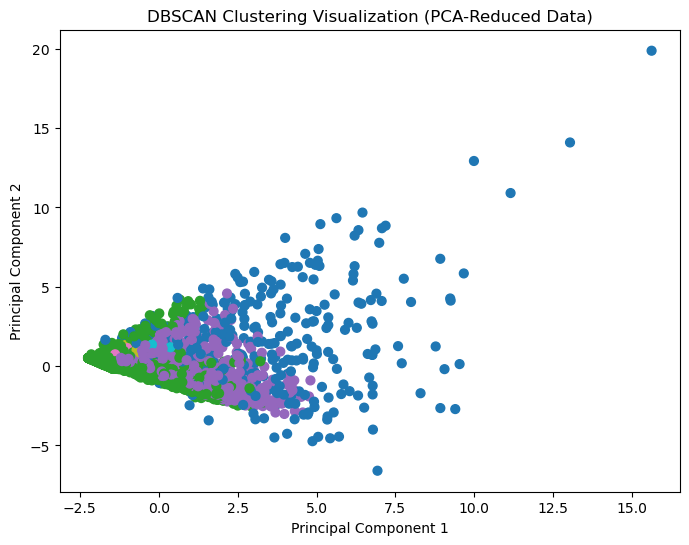

In [57]:
df_pca['DBSCAN_Cluster'] = dbscan.labels_

plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], 
            c=df_pca['DBSCAN_Cluster'], 
            cmap='tab10', s=40)
plt.title("DBSCAN Clustering Visualization (PCA-Reduced Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [61]:
# Task 5 : Evaluation and Performance Metrics

In [ ]:
# 1) In KMeans Algorithm, we choose K=5 even though it's silhoutte score is a bit low.
# The reason behind it is that it produces more meaningful and realistic groups and it is normal for overlapping of clusters.
# 2) In DBSCAN Algorithm, we choose eps=1.5 and min_samples=5 as it had better silhoutte score and noise level.
# It includes noise level so that unusual patterns can be identified.
#Overall, K-Means provides structured segmentation suitable for marketing strategies, 
# while DBSCAN uncovers unusual customer behaviors and anomalies, making the two methods complementary for airline customer analysis.